In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 1.Data Extraction

In [66]:
df = pd.read_csv("C:/Users/shreya/EDA/flipkart_mobiles.csv")

In [67]:
df

,Brand,Model,Color,Storage,RAM,Battery,Display_Size,Rating
0,POCO,C71,Cool Blue,128 GB ROM,6 GB RAM,5200 mAh,6.88 inch,4.1
1,POCO,M7 5G,Ocean Blue,128 GB ROM,6 GB RAM,5160 mAh,6.88 inch,4.1
2,Samsung,Galaxy F06 5G,Bahama Blue,128 GB ROM,6 GB RAM,5000 mAh,6.7 inch,4.2
3,Samsung,Galaxy F06 5G,Bahama Blue,64 GB ROM,4 GB RAM,5000 mAh,6.7 inch,4.1
4,POCO,M7 Pro 5G,Lunar Dust,128 GB ROM,6 GB RAM,5110 mAh,6.67 inch,4.3
...,...,...,...,...,...,...,...,...
595,Kechaoda,NaN,NaN,NaN,NaN,850 mAh,1.44 inch,4.1
596,OPPO,NaN,Dusk Pink,256 GB ROM,8 GB RAM,5000 mAh,6.7 inch,4.4
597,Samsung,Galaxy Z Fold6 5G,Pink,256 GB ROM,12 GB RAM,4400 mAh,7.6 inch,4.3
598,itel,NaN,NaN,NaN,NaN,1000 mAh,1.8 inch,4.1


## Data Transformation

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         600 non-null    object 
 1   Model         473 non-null    object 
 2   Color         520 non-null    object 
 3   Storage       529 non-null    object 
 4   RAM           495 non-null    object 
 5   Battery       575 non-null    object 
 6   Display_Size  584 non-null    object 
 7   Rating        599 non-null    float64
dtypes: float64(1), object(7)
memory usage: 37.6+ KB


In [69]:
df.head()

,Brand,Model,Color,Storage,RAM,Battery,Display_Size,Rating
0,POCO,C71,Cool Blue,128 GB ROM,6 GB RAM,5200 mAh,6.88 inch,4.1
1,POCO,M7 5G,Ocean Blue,128 GB ROM,6 GB RAM,5160 mAh,6.88 inch,4.1
2,Samsung,Galaxy F06 5G,Bahama Blue,128 GB ROM,6 GB RAM,5000 mAh,6.7 inch,4.2
3,Samsung,Galaxy F06 5G,Bahama Blue,64 GB ROM,4 GB RAM,5000 mAh,6.7 inch,4.1
4,POCO,M7 Pro 5G,Lunar Dust,128 GB ROM,6 GB RAM,5110 mAh,6.67 inch,4.3


In [70]:
df.isnull().sum()

Brand             0
Model           127
Color            80
Storage          71
RAM             105
Battery          25
Display_Size     16
Rating            1
dtype: int64

In [71]:
df["Brand"] = df["Brand"].astype("category")

In [72]:
df["Color"] = df["Color"].astype("category")

In [73]:
df["Model"] = df["Model"].astype("object")

In [74]:
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

In [75]:
df["Storage"] = df["Storage"].str.extract(r"(\d+)").astype(float)
df["RAM"] = df["RAM"].str.extract(r"(\d+)").astype(float)
df["Battery"] = df["Battery"].str.extract(r"(\d+)").astype(float)
df["Display_Size"] = df["Display_Size"].str.extract(r"(\d+\.\d+)").astype(float)

# Data Exploration

In [76]:
df.shape

(600, 8)

In [77]:
df.describe()

,Storage,RAM,Battery,Display_Size,Rating
count,529.000000,495.000000,575.000000,584.000000,599.000000
mean,165.693762,7.163636,5064.438261,6.075594,4.281636
std,84.664248,2.361013,1691.563861,1.662433,0.237032
min,0.000000,3.000000,800.000000,0.660000,2.600000
25%,128.000000,6.000000,5000.000000,6.670000,4.200000
50%,128.000000,8.000000,5160.000000,6.700000,4.300000
75%,256.000000,8.000000,6000.000000,6.780000,4.400000
max,512.000000,16.000000,7550.000000,7.600000,4.800000


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Brand         600 non-null    category
 1   Model         473 non-null    object  
 2   Color         520 non-null    category
 3   Storage       529 non-null    float64 
 4   RAM           495 non-null    float64 
 5   Battery       575 non-null    float64 
 6   Display_Size  584 non-null    float64 
 7   Rating        599 non-null    float64 
dtypes: category(2), float64(5), object(1)
memory usage: 41.2+ KB


In [79]:
df.isnull().sum()

Brand             0
Model           127
Color            80
Storage          71
RAM             105
Battery          25
Display_Size     16
Rating            1
dtype: int64

In [80]:
df.columns

Index(['Brand', 'Model', 'Color', 'Storage', 'RAM', 'Battery', 'Display_Size',
       'Rating'],
      dtype='object')

# 3.Data Cleaning

# a.Missing Values

In [81]:
# check for missing values
df.isnull().sum()

Brand             0
Model           127
Color            80
Storage          71
RAM             105
Battery          25
Display_Size     16
Rating            1
dtype: int64

In [82]:
# filling missing values for Categorical columns

In [83]:
df["Model"] = df["Model"].fillna("Unknown")
df["Color"] = df["Color"].astype(str).fillna("Not Specified")

In [84]:
## Filling missing values for numerical columns

In [85]:
df["Storage"] = df["Storage"].fillna(df["Storage"].median())
df["RAM"] = df["RAM"].fillna(df["RAM"].median())

In [86]:
df["Battery"] = df["Battery"].fillna(df["Battery"].median())
df["Display_Size"] = df["Display_Size"].fillna(df["Display_Size"].median())
df["Rating"] = df["Rating"].fillna(df["Rating"].mean())

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Brand         600 non-null    category
 1   Model         600 non-null    object  
 2   Color         600 non-null    object  
 3   Storage       600 non-null    float64 
 4   RAM           600 non-null    float64 
 5   Battery       600 non-null    float64 
 6   Display_Size  600 non-null    float64 
 7   Rating        600 non-null    float64 
dtypes: category(1), float64(5), object(2)
memory usage: 34.8+ KB


In [88]:
df.isnull().sum()

Brand           0
Model           0
Color           0
Storage         0
RAM             0
Battery         0
Display_Size    0
Rating          0
dtype: int64

# b.Outliers

In [89]:
# Define function to detect outliers for any numeric column
def detect_outliers_df(df, col):
    series = df[col].dropna()
    if series.empty:
        return pd.DataFrame()

      
    # Calculate IQR (Interquartile Range)
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Detect outliers
    outliers_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    return df[outliers_mask]

#  Detect outliers 
outliers_storage = detect_outliers_df(df, 'Storage')
outliers_ram = detect_outliers_df(df, 'RAM')
outliers_battery = detect_outliers_df(df, 'Battery')
outliers_display = detect_outliers_df(df, 'Display_Size')
outliers_rating = detect_outliers_df(df, 'Rating')



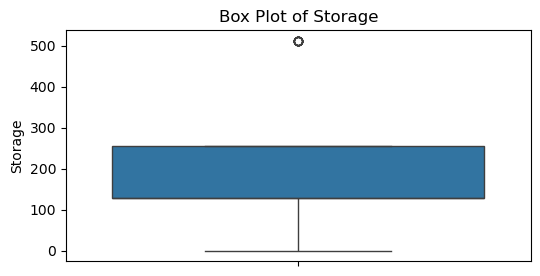

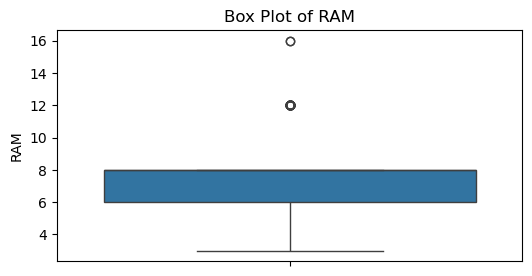

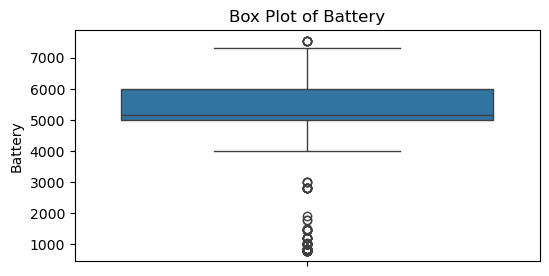

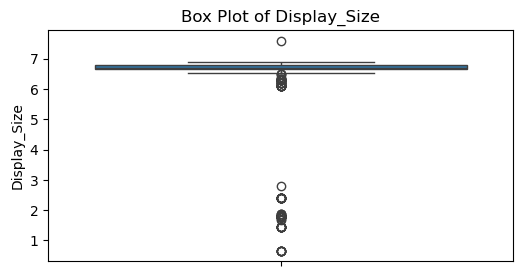

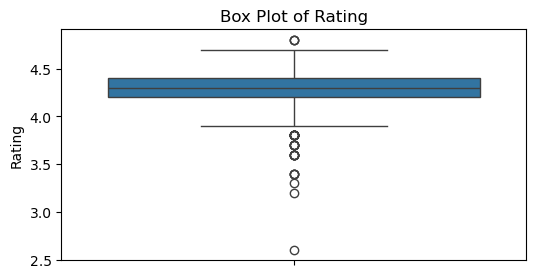

In [90]:
# Using Box Plot for all numeric columns
for col in df.select_dtypes(include=[np.number]).columns:
    plt.figure(figsize=(6, 3))
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()

# d.Structural Error

In [91]:
df.head(5)

,Brand,Model,Color,Storage,RAM,Battery,Display_Size,Rating
0,POCO,C71,Cool Blue,128.0,6.0,5200.0,6.88,4.1
1,POCO,M7 5G,Ocean Blue,128.0,6.0,5160.0,6.88,4.1
2,Samsung,Galaxy F06 5G,Bahama Blue,128.0,6.0,5000.0,6.70,4.2
3,Samsung,Galaxy F06 5G,Bahama Blue,64.0,4.0,5000.0,6.70,4.1
4,POCO,M7 Pro 5G,Lunar Dust,128.0,6.0,5110.0,6.67,4.3


In [92]:
df.rename(columns={
    "Brand": "Phone Brand",
    "Model": "Model Name",
    "Color": "Color Variant",
    "Storage": "Storage (GB)",
    "RAM": "RAM (GB)",
    "Battery": "Battery (mAh)",
    "Display_Size": "Display Size (inches)",
    "Rating": "User Rating"
}, inplace=True)

df.head(10)


,Phone Brand,Model Name,Color Variant,Storage (GB),RAM (GB),Battery (mAh),Display Size (inches),User Rating
0,POCO,C71,Cool Blue,128.0,6.0,5200.0,6.88,4.1
1,POCO,M7 5G,Ocean Blue,128.0,6.0,5160.0,6.88,4.1
2,Samsung,Galaxy F06 5G,Bahama Blue,128.0,6.0,5000.0,6.70,4.2
3,Samsung,Galaxy F06 5G,Bahama Blue,64.0,4.0,5000.0,6.70,4.1
4,POCO,M7 Pro 5G,Lunar Dust,128.0,6.0,5110.0,6.67,4.3
5,POCO,C71,Desert Gold,64.0,4.0,5200.0,6.88,3.8
6,POCO,C71,Power Black,128.0,6.0,5200.0,6.88,4.1
7,POCO,M7 5G,Mint Green,128.0,8.0,5160.0,6.88,4.2
8,vivo,T4x 5G,Marine Blue,128.0,8.0,6500.0,6.72,4.4
9,POCO,M7 5G,Mint Green,128.0,6.0,5160.0,6.88,4.1


In [93]:
df

,Phone Brand,Model Name,Color Variant,Storage (GB),RAM (GB),Battery (mAh),Display Size (inches),User Rating
0,POCO,C71,Cool Blue,128.0,6.0,5200.0,6.88,4.1
1,POCO,M7 5G,Ocean Blue,128.0,6.0,5160.0,6.88,4.1
2,Samsung,Galaxy F06 5G,Bahama Blue,128.0,6.0,5000.0,6.70,4.2
3,Samsung,Galaxy F06 5G,Bahama Blue,64.0,4.0,5000.0,6.70,4.1
4,POCO,M7 Pro 5G,Lunar Dust,128.0,6.0,5110.0,6.67,4.3
...,...,...,...,...,...,...,...,...
595,Kechaoda,Unknown,nan,128.0,8.0,850.0,1.44,4.1
596,OPPO,Unknown,Dusk Pink,256.0,8.0,5000.0,6.70,4.4
597,Samsung,Galaxy Z Fold6 5G,Pink,256.0,12.0,4400.0,7.60,4.3
598,itel,Unknown,nan,128.0,8.0,1000.0,1.80,4.1


In [94]:
df.dtypes

Phone Brand              category
Model Name                 object
Color Variant              object
Storage (GB)              float64
RAM (GB)                  float64
Battery (mAh)             float64
Display Size (inches)     float64
User Rating               float64
dtype: object

# 3.Data Manipulation

## Top 10 Mobile Brands Based on Ratings

In [95]:
import pandas as pd
# and you have columns like: 'Brand', 'Rating', 'Price', 'RAM', 'Storage', etc.

# Convert Rating to numeric (in case it was scraped as string)
df['User Rating'] = pd.to_numeric(df['User Rating'], errors='coerce')

# Group by brand and calculate average rating and count of phones
brand_rating = (
    df.groupby('Phone Brand')
      .agg(Average_Rating=('User Rating', 'mean'),
           Total_Phones=('Phone Brand', 'count'))
      .reset_index()
)

# Sort by average rating (descending) and take top 10 brands
top_10_brands = brand_rating.sort_values(by='Average_Rating', ascending=False).head(10)

# Display the result
print(top_10_brands)


   Phone Brand  Average_Rating  Total_Phones
1        Apple        4.676000            25
17     Nothing        4.490909            11
19     OnePlus        4.486957            23
29        vivo        4.428571            28
7         IQOO        4.408824            34
2          CMF        4.400000             8
18        OPPO        4.392593            27
15    Motorola        4.370000            10
3       Google        4.370000            10
27      realme        4.363636            77


C:\Users\shreya\AppData\Local\Temp\ipykernel_141952\1498515269.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Phone Brand')


In [97]:
# Group by brand and calculate average rating and count of phones
brand_rating = (
    df.groupby('Phone Brand')
      .agg(Average_Rating=('User Rating', 'mean'),
           Total_Phones=('Phone Brand', 'count'))
      .reset_index()
)

# Sort by average rating (descending) and take top 10 brands
top_10_brands = brand_rating.sort_values(by='Average_Rating', ascending=False).head(10)

# Display the result
print(top_10_brands)


   Phone Brand  Average_Rating  Total_Phones
1        Apple        4.676000            25
17     Nothing        4.490909            11
19     OnePlus        4.486957            23
29        vivo        4.428571            28
7         IQOO        4.408824            34
2          CMF        4.400000             8
18        OPPO        4.392593            27
15    Motorola        4.370000            10
3       Google        4.370000            10
27      realme        4.363636            77


C:\Users\shreya\AppData\Local\Temp\ipykernel_141952\3946361629.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Phone Brand')


## Phones that have 8GB RAM and 128GB Storage

In [43]:
df_filtered = df[(df["RAM (GB)"] == 8) & (df["Storage (GB)"] == 128)]
df_filtered.head()


,Phone Brand,Model Name,Color Variant,Storage (GB),RAM (GB),Battery (mAh),Display Size (inches),User Rating
7,POCO,M7 5G,Mint Green,128.0,8.0,5160.0,6.88,4.2
8,vivo,T4x 5G,Marine Blue,128.0,8.0,6500.0,6.72,4.4
15,Motorola,g45 5G,Brilliant Green,128.0,8.0,5000.0,6.50,4.3
29,MOTOROLA,G96 5G,Pantone Greener Pastures,128.0,8.0,5500.0,6.67,4.4
30,OPPO,Unknown,Prism Black,128.0,8.0,7000.0,6.67,4.5


## Phones that belong to “Samsung” brand and have Display Size greater than 6.5 inches

In [46]:
df_filtered = df[(df["Phone Brand"] == "Samsung") & (df["Display Size (inches)"] > 6.5)]
df_filtered.head()



,Phone Brand,Model Name,Color Variant,Storage (GB),RAM (GB),Battery (mAh),Display Size (inches),User Rating
2,Samsung,Galaxy F06 5G,Bahama Blue,128.0,6.0,5000.0,6.7,4.2
3,Samsung,Galaxy F06 5G,Bahama Blue,64.0,4.0,5000.0,6.7,4.1
11,Samsung,Galaxy F06 5G,Lit Violet,64.0,4.0,5000.0,6.7,4.1
13,Samsung,Galaxy F06 5G,Bahama Blue,128.0,4.0,5000.0,6.7,4.1
18,Samsung,Galaxy F06 5G,Lit Violet,128.0,6.0,5000.0,6.7,4.2


## Phones that have Battery capacity more than 5000 mAh and Rating above 4.2

In [49]:
df_filtered = df[(df["Battery (mAh)"] > 5000) & (df["User Rating"] > 4.2)]
df_filtered.head()


,Phone Brand,Model Name,Color Variant,Storage (GB),RAM (GB),Battery (mAh),Display Size (inches),User Rating
4,POCO,M7 Pro 5G,Lunar Dust,128.0,6.0,5110.0,6.67,4.3
8,vivo,T4x 5G,Marine Blue,128.0,8.0,6500.0,6.72,4.4
10,MOTOROLA,Edge 60 Fusion 5G,PANTONE Slipstream,256.0,8.0,5500.0,6.67,4.4
14,POCO,M7 Pro 5G,Lavender Frost,128.0,6.0,5110.0,6.67,4.3
22,MOTOROLA,Edge 60 Fusion 5G,PANTONE Mykonos Blue,256.0,8.0,5500.0,6.67,4.4


## Phones with 12GB RAM and not having “Black” color

In [51]:
df_filtered = df[(df["RAM (GB)"] == 12) & (~df["Color Variant"].str.contains("Black", case=False, na=False))]
df_filtered.head()



,Phone Brand,Model Name,Color Variant,Storage (GB),RAM (GB),Battery (mAh),Display Size (inches),User Rating
96,MOTOROLA,Edge 60 Fusion 5G,PANTONE Slipstream,256.0,12.0,5500.0,6.67,4.5
137,realme,P3 Ultra 5G,Orion Red,256.0,12.0,6000.0,6.83,4.5
147,vivo,T4 5G,Phantom Grey,256.0,12.0,7300.0,6.77,4.5
170,realme,P3 Ultra 5G,Orion Red,256.0,12.0,6000.0,6.83,4.5
180,realme,P3 Ultra 5G,Glowing Lunar White,256.0,12.0,6000.0,6.83,4.5


In [ ]:

plt.style.use("seaborn-v0_8-whitegrid")


# Data Visualization

## Univariate Analysis

#### Distribution of Phone Ratings

In [ ]:
### 1.What is the distribution of user ratings across all mobile phones in the dataset

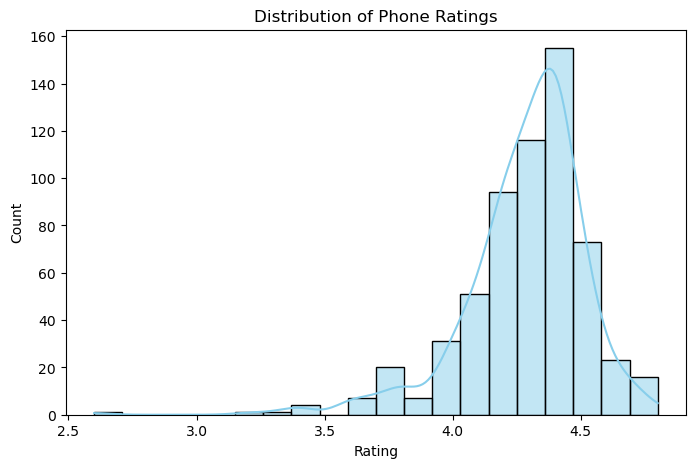

In [52]:
plt.figure(figsize=(8,5))
sns.histplot(df["User Rating"], bins=20, kde=True, color='skyblue')
plt.title("Distribution of Phone Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


In [ ]:
## 2.Which are the top 10 most popular phone brands based on their frequency in the dataset?

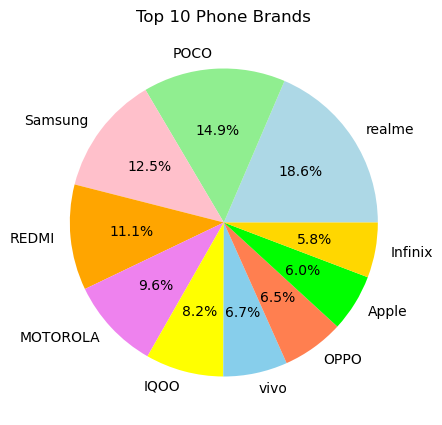

In [56]:
top_brands = df["Phone Brand"].value_counts().head(10)

plt.figure(figsize=(6,5))
top_brands.plot.pie(autopct='%1.1f%%', colors=['lightblue', 'lightgreen', 'pink', 'orange', 'violet', 
                                               'yellow', 'skyblue', 'coral', 'lime', 'gold'])
plt.title('Top 10 Phone Brands')
plt.ylabel('')
plt.show()



## Bivariate Analysis

### RAM vs User Rating (Scatter Plot)

In [ ]:
## 3.How does the amount of RAM (in GB) affect user ratings across different mobile phone brands?

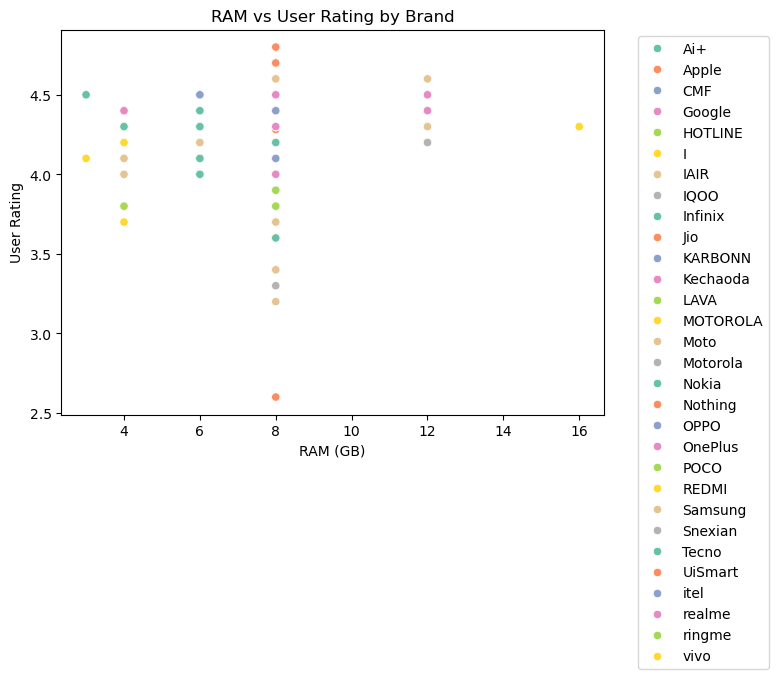

In [67]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="RAM (GB)", y="User Rating", data=df, hue="Phone Brand", palette="Set2")
plt.title("RAM vs User Rating by Brand")
plt.xlabel("RAM (GB)")
plt.ylabel("User Rating")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


## Multivariate Analysis

### Box Plot of Rating by Brand

In [ ]:
## 4.What is the distribution of user ratings among the top 5 mobile phone brands, and which brand shows the 
  highest consistency or variation in ratings?

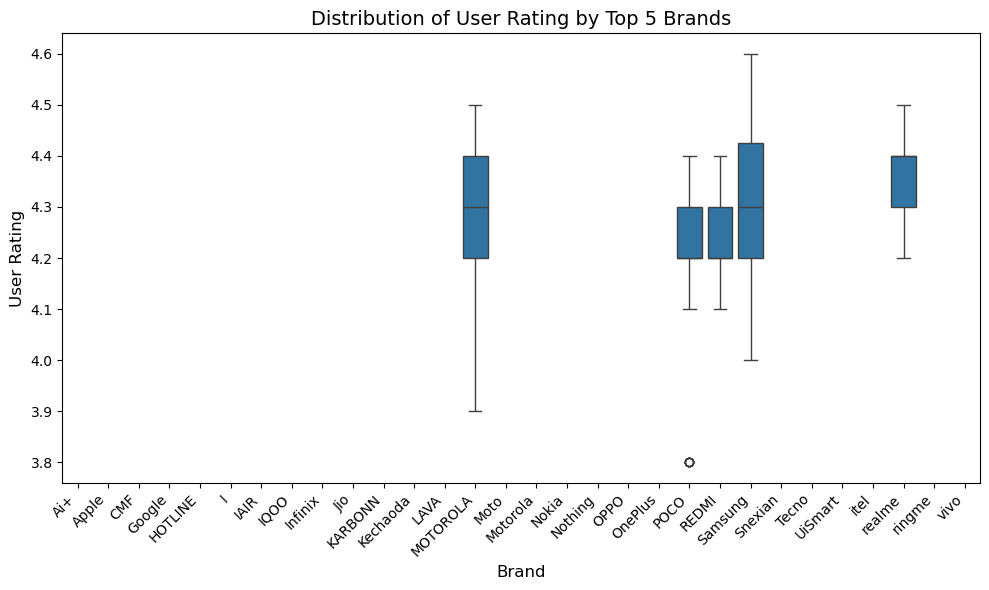

In [73]:
plt.figure(figsize=(10,6))
top_5_brands = df['Phone Brand'].value_counts().head(5).index
sns.boxplot(data=df[df['Phone Brand'].isin(top_5_brands)], 
            x='Phone Brand', y='User Rating')

plt.title("Distribution of User Rating by Top 5 Brands", fontsize=14)
plt.xlabel("Brand", fontsize=12)
plt.ylabel("User Rating", fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotate labels and align to right
plt.tight_layout()  # Adjust spacing automatically
plt.show()


### Heatmap of Numeric Correlations

In [ ]:
## 5.What is the correlation between different numerical features (like storage, RAM, battery, display size, and user rating) in the mobile phone dataset?

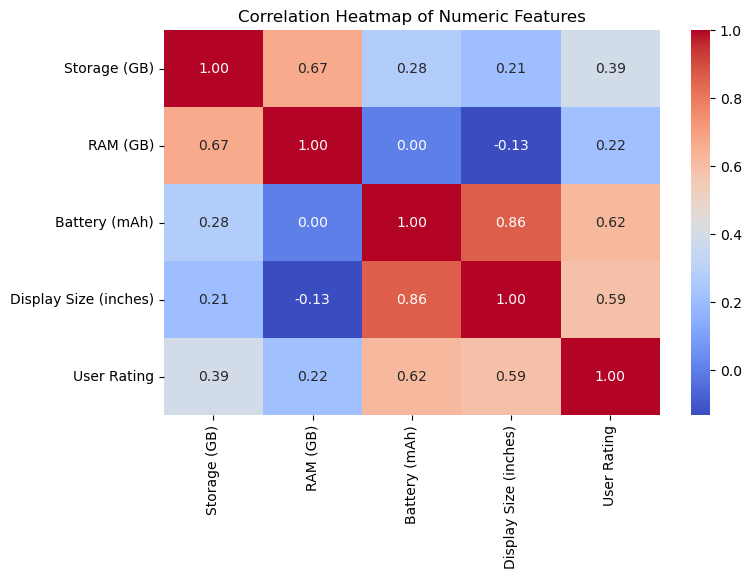

In [72]:
plt.figure(figsize=(8,5))
numeric_df = df.select_dtypes(include=['int64', 'float64'])  # only numeric columns
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()
